In [1]:
# WEEK 3 - Supply chain Analysis

In [2]:
## Task 1 - Loading the dataset

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("SCMS Delivery History Dataset.csv")

In [5]:
df.head(10)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN
5,23,112-NG-T01,Pre-PQ Process,SCMS-87,ASN-57,Nigeria,PMO - US,Direct Drop,EXW,Air,...,240,416,2225.60,5.35,0.02,"Aurobindo Unit III, India",Yes,504,5920.42,NaN
6,44,110-ZM-T01,Pre-PQ Process,SCMS-139,ASN-130,Zambia,PMO - US,Direct Drop,DDU,Air,...,90,135,4374.00,32.40,0.36,MSD South Granville Australia,Yes,328,Freight Included in Commodity Cost,NaN
7,45,109-TZ-T01,Pre-PQ Process,SCMS-140,ASN-94,Tanzania,PMO - US,Direct Drop,EXW,Air,...,60,16667,60834.55,3.65,0.06,"Aurobindo Unit III, India",Yes,1478,6212.41,NaN
8,46,112-NG-T01,Pre-PQ Process,SCMS-156,ASN-93,Nigeria,PMO - US,Direct Drop,EXW,Air,...,60,273,532.35,1.95,0.03,"Aurobindo Unit III, India",No,See ASN-93 (ID#:1281),See ASN-93 (ID#:1281),NaN
9,47,110-ZM-T01,Pre-PQ Process,SCMS-165,ASN-199,Zambia,PMO - US,Direct Drop,CIP,Air,...,120,2800,115080.00,41.10,0.34,ABBVIE (Abbott) St. P'burg USA,Yes,643,Freight Included in Commodity Cost,NaN


In [6]:
print("Shape of dataset:" , df.shape)

Shape of dataset: (10324, 33)


In [7]:
print(df.columns.tolist())

['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)']


In [8]:
# Task 2 - Cleaning Data

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

In [10]:
date_columns = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date',
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors = 'coerce')

print("Date columns converted successfully.")

/tmp/ipykernel_4869/3840023524.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors = 'coerce')
/tmp/ipykernel_4869/3840023524.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors = 'coerce')
/tmp/ipykernel_4869/3840023524.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors = 'coerce')
/tmp/ipykernel_4869/3840023524.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is 

Date columns converted successfully.


In [11]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Shipment Mode                    360
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Dosage                          1736
Line Item Insurance (USD)        287
dtype: int64

In [12]:
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')
df['Dosage'] = df['Dosage'].fillna('Unknown')
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)

print("Missing values handled successfully.")

Missing values handled successfully.


In [13]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                             0
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [14]:
df.head()


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,0.0
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,0.0
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,0.0
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,0.0
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,0.0


In [15]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                             0
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [16]:
# Converting Numeric Columns

In [17]:
numeric_columns = [
    'Line Item Quantity',
    'Line Item Value',
    'Pack Price',
    'Unit Price',
    'Weight (Kilograms)',
    'Freight Cost (USD)',
    'Line Item Insurance (USD)'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

print("Numeric columns converted successfully.")

Numeric columns converted successfully.


In [18]:
df[numeric_columns].dtypes

Line Item Quantity             int64
Line Item Value              float64
Pack Price                   float64
Unit Price                   float64
Weight (Kilograms)           float64
Freight Cost (USD)           float64
Line Item Insurance (USD)    float64
dtype: object

In [20]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                             0
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [21]:
df['Weight (Kilograms)'] = df['Weight (Kilograms)'].fillna(0)
df['Freight Cost (USD)'] = df['Freight Cost (USD)'].fillna(0)

In [22]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                             0
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [23]:
# Task 3 - Exploratory Data Analysis (EDA)

In [37]:
most_common_mode = df['Shipment Mode'].mode()[0]

print("Most Common Shipment Mode:", most_common_mode)

Most Common Shipment Mode: Air


In [38]:
shipments_per_country = (
    df.groupby('Country')
    .size()
    .sort_values(ascending = False)
)

shipments_per_country

Country
South Africa          1406
Nigeria               1194
Côte d'Ivoire         1083
Uganda                 779
Vietnam                688
Zambia                 683
Haiti                  655
Mozambique             631
Zimbabwe               538
Tanzania               519
Rwanda                 430
Congo, DRC             333
Guyana                 237
Ethiopia               216
South Sudan            164
Kenya                  111
Burundi                 98
Namibia                 95
Cameroon                75
Botswana                70
Ghana                   58
Dominican Republic      52
Sudan                   46
Swaziland               35
Mali                    17
Pakistan                15
Guatemala               15
Malawi                  14
Benin                   13
Lebanon                  8
Libya                    8
Angola                   7
Liberia                  6
Lesotho                  4
Sierra Leone             4
Togo                     3
Senegal             

In [40]:
df['Delivery Delay (Days)'] = (
    df['Delivered to Client Date']
    - df['Scheduled Delivery Date']
).dt.days

df[['Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Delay (Days)']]

,Scheduled Delivery Date,Delivered to Client Date,Delivery Delay (Days)
0,2006-06-02,2006-06-02,0
1,2006-11-14,2006-11-14,0
2,2006-08-27,2006-08-27,0
3,2006-09-01,2006-09-01,0
4,2006-08-11,2006-08-11,0
...,...,...,...
10319,2015-07-31,2015-07-15,-16
10320,2015-07-31,2015-08-06,6
10321,2015-08-31,2015-08-25,-6
10322,2015-09-09,2015-08-04,-36


In [41]:
average_delay = df['Delivery Delay (Days)'].mean()
print("Average Delivery Delay (Days):", average_delay)

Average Delivery Delay (Days): -6.023537388609066


In [43]:
delayed_shipments = df[df['Delivery Delay (Days)'] > 0 ]
print("Number of Delayed Shipments:", delayed_shipments.shape[0])

Number of Delayed Shipments: 1186


In [46]:
total_freight = df['Freight Cost (USD)'].sum()
print("Total Freight Cost:", total_freight)

Total Freight Cost: 68817849.41


In [48]:
avg_line_value = df['Line Item Value'].mean()
print("Average Line Item Value:", avg_line_value)

Average Line Item Value: 157650.56734695853


In [49]:
total_insurance = df['Line Item Insurance (USD)'].sum()
print("Total Insurance Cost:",total_insurance)

Total Insurance Cost: 2410060.61


In [50]:
# Task 4 - Group Based Analysis

In [52]:
# 1. Country VS Total Shipments
country_shipments = (
    df.groupby('Country')
    .size()
    .reset_index(name ='Total Shipments')
    .sort_values(by = 'Total Shipments', ascending = False)
)

country_shipments

,Country,Total Shipments
33,South Africa,1406
28,Nigeria,1194
9,Côte d'Ivoire,1083
39,Uganda,779
40,Vietnam,688
41,Zambia,683
16,Haiti,655
26,Mozambique,631
42,Zimbabwe,538
37,Tanzania,519


In [53]:
# 2. Vendor Vs Total Cost
vendor_cost = (
    df.groupby('Vendor')['Line Item Value']
    .sum()
    .reset_index( name = 'Total Cost')
    .sort_values( by = 'Total Cost', ascending = False)
)

vendor_cost

,Vendor,Total Cost
59,SCMS from RDC,1.085372e+09
50,"Orgenics, Ltd",1.477034e+08
13,Aurobindo Pharma Limited,9.138371e+07
46,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,7.221367e+07
28,HETERO LABS LIMITED,4.288157e+07
...,...,...
48,OMEGA DIAGNOSTICS LTD,1.375000e+03
56,RANBAXY Fine Chemicals LTD.,1.102000e+03
16,BIO-RAD LABORATORIES PTY LTD. (SOUTH AFRICA),7.502900e+02
36,INVERNESS MEDICAL INNOVATIONS SOUTH AFRICA (PT...,7.150000e+02


In [55]:
# 3. Product Group vs Total Value
product_group_value = (
    df.groupby('Product Group')['Line Item Value']
    .sum()
    .reset_index( name = 'Total Value')
    .sort_values(by = 'Total Value', ascending = False)
)

product_group_value

,Product Group,Total Value
2,ARV,1.413220e+09
3,HRDT,2.133448e+08
0,ACT,6.643809e+05
1,ANTM,2.741766e+05
4,MRDT,8.106510e+04


In [56]:
# 4. Shipment Mode vs Average Delay
shipment_delay = (
    df.groupby('Shipment Mode')['Delivery Delay (Days)']
    .mean()
    .reset_index(name = 'Average Delay (Days)')
    .sort_values(by = 'Average Delay (Days)', ascending = False)
)
shipment_delay

,Shipment Mode,Average Delay (Days)
2,Ocean,5.870620
4,Unknown,-2.511111
0,Air,-3.763782
3,Truck,-9.921908
1,Air Charter,-19.036923


In [57]:
# Task 5 - Data Visualization
import matplotlib.pyplot as plt

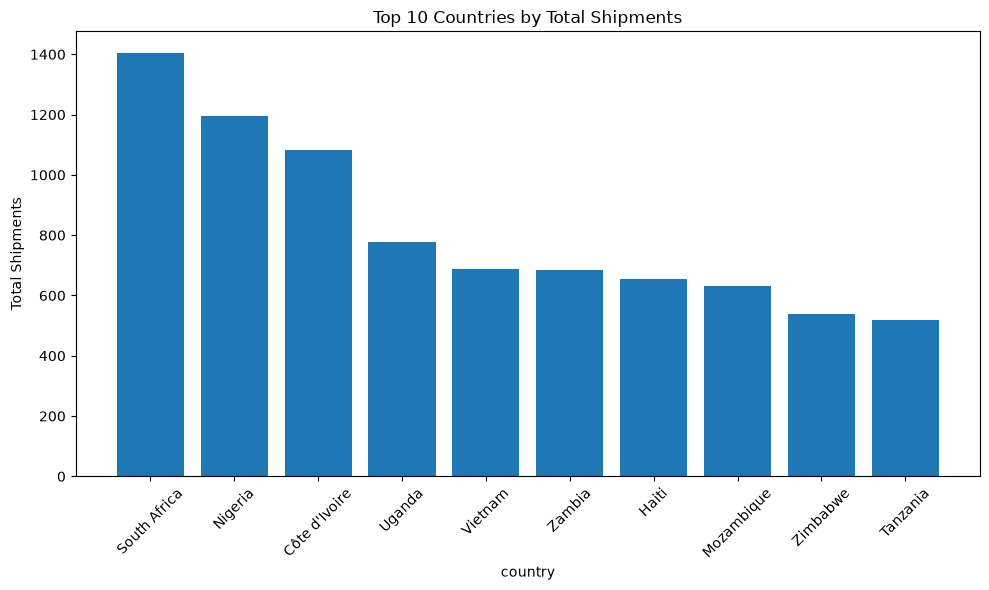

In [59]:
# Bar Chart
top10_countries = country_shipments.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_countries['Country'], top10_countries['Total Shipments'])

plt.title("Top 10 Countries by Total Shipments")
plt.xlabel("country")
plt.ylabel("Total Shipments")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

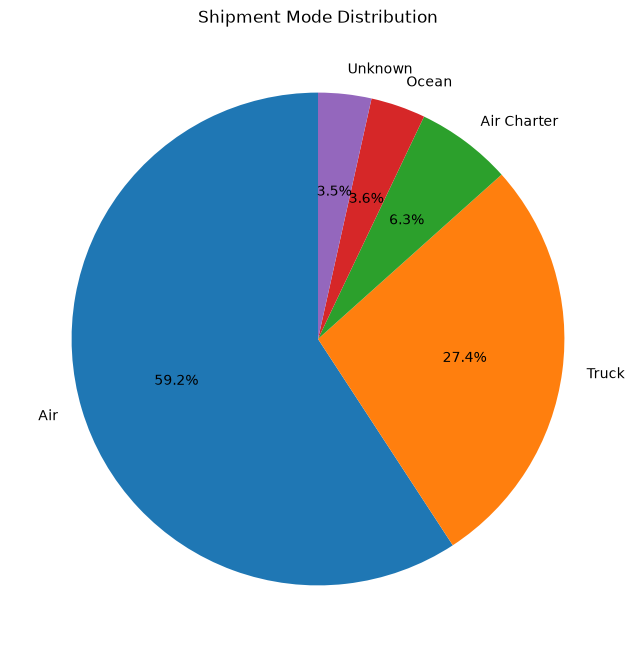

In [60]:
# Pie Chart
shipment_distribution = df['Shipment Mode'].value_counts()

plt.figure(figsize = (8, 8))

plt.pie(
    shipment_distribution,
    labels = shipment_distribution.index,
    autopct= '%1.1f%%',
    startangle = 90
)

plt.title("Shipment Mode Distribution")

plt.show()

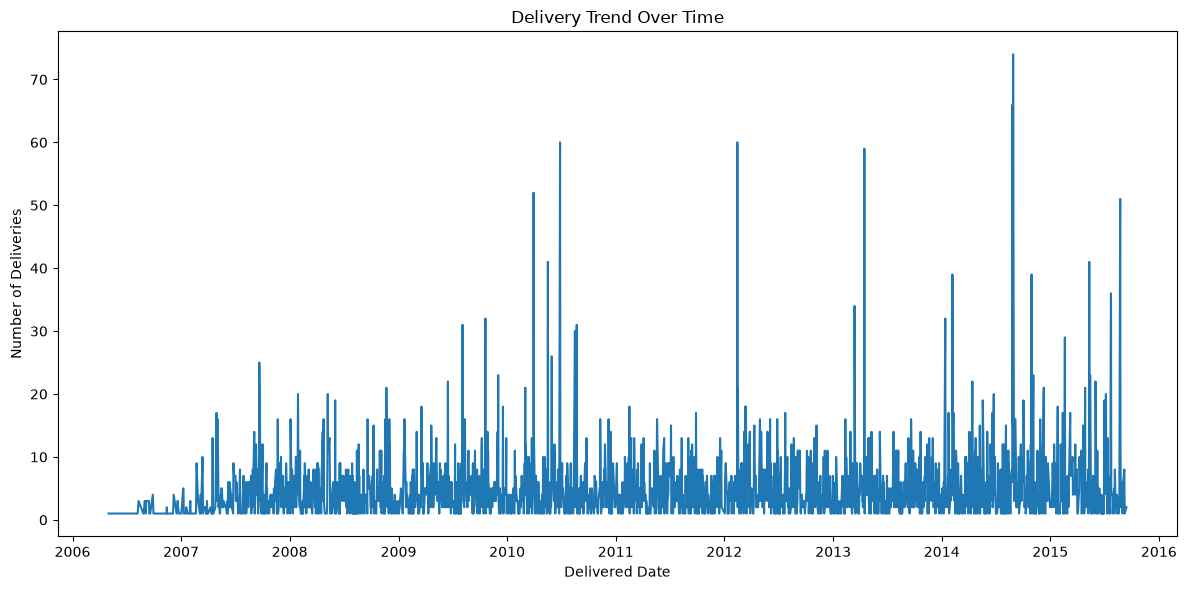

In [63]:
# Line Chart
delivery_trend = (
    df.groupby('Delivered to Client Date')
    .size()
)

plt.figure(figsize=(12,6))

plt.plot(delivery_trend.index, delivery_trend.values)

plt.title("Delivery Trend Over Time")
plt.xlabel("Delivered Date")
plt.ylabel("Number of Deliveries")

plt.tight_layout()

plt.show()

In [64]:
df.to_csv("SCMS_Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
